In [41]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

import lightgbm as lgb
import xgboost as xgb
import optuna

In [2]:
train = pd.read_csv("train.csv", index_col="PassengerId")
test = pd.read_csv("test.csv", index_col="PassengerId")

In [3]:
train.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'Deck', 'Title',
       'FamilySize', 'IsAlone', 'FamilyCategory', 'Log_Fare', 'IsChild',
       'TicketFrequency'],
      dtype='str')

In [4]:
train.isnull().sum().sort_values(ascending=False).head(10)

Survived      0
Pclass        0
Sex           0
Age           0
Fare          0
Embarked      0
Deck          0
Title         0
FamilySize    0
IsAlone       0
dtype: int64

In [5]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 1 to 891
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Survived         891 non-null    int64  
 1   Pclass           891 non-null    int64  
 2   Sex              891 non-null    str    
 3   Age              891 non-null    int64  
 4   Fare             891 non-null    float64
 5   Embarked         891 non-null    str    
 6   Deck             891 non-null    str    
 7   Title            891 non-null    str    
 8   FamilySize       891 non-null    int64  
 9   IsAlone          891 non-null    int64  
 10  FamilyCategory   891 non-null    str    
 11  Log_Fare         891 non-null    float64
 12  IsChild          891 non-null    int64  
 13  TicketFrequency  891 non-null    int64  
dtypes: float64(2), int64(7), str(5)
memory usage: 97.6 KB


In [6]:
#Baseline Logistic Regression

In [7]:
X_logistic = train.drop(columns=["Survived", "Fare", "FamilySize"])
X_logistic_test = test.drop(columns=["Fare", "FamilySize"])
y = train["Survived"]

In [8]:
X_logistic.columns

Index(['Pclass', 'Sex', 'Age', 'Embarked', 'Deck', 'Title', 'IsAlone',
       'FamilyCategory', 'Log_Fare', 'IsChild', 'TicketFrequency'],
      dtype='str')

In [9]:
X_logistic_test[X_logistic_test.Log_Fare.isnull()]

,Pclass,Sex,Age,Embarked,Deck,Title,IsAlone,FamilyCategory,Log_Fare,IsChild,TicketFrequency
PassengerId,,,,,,,,,,,
1044,3,male,60,S,0,Mr,1,Alone,NaN,0,1


In [10]:
#Denn die TicketFrequency ist U Förmig mit Survived Korreliert
def ticket_freq_category(freq):
    if freq == 1:
        return 'Solo'
    elif freq <= 4:
        return 'Small'
    else:
        return 'Large'

X_logistic['TicketFreqCategory'] = X_logistic['TicketFrequency'].apply(ticket_freq_category)
X_logistic = X_logistic.drop(columns=['TicketFrequency'])

X_logistic_test['TicketFreqCategory'] = X_logistic_test['TicketFrequency'].apply(ticket_freq_category)
X_logistic_test = X_logistic_test.drop(columns=['TicketFrequency'])

In [11]:
numeric_cols_logistic = X_logistic.select_dtypes(include="number").columns
categorical_cols_logistic = X_logistic.select_dtypes(include="str").columns
categorical_cols_logistic

Index(['Sex', 'Embarked', 'Deck', 'Title', 'FamilyCategory',
       'TicketFreqCategory'],
      dtype='str')

In [34]:
numeric_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_preprocessor = Pipeline([
    ("onehot", OneHotEncoder(drop='first', handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("numeric_preprocessor", numeric_preprocessor, numeric_cols_logistic),
    ("categorical_preprocessor", categorical_preprocessor, categorical_cols_logistic),
])
Baseline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression())
])
Baseline.fit(X_logistic, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['Pclass','Sex','Age',...,'Log_Fare','IsChild','TicketFreqCategory']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric_preprocessor', ...), ('categorical_preprocessor', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By spec

In [35]:
Fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [36]:
cross_val_score(Baseline, X_logistic, y, cv=Fold, scoring="accuracy").mean()

/Users/andyzhu/PycharmProjects/Kaggle_Titanic/.venv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


np.float64(0.8293892411022534)

In [15]:
def submission(model, X_test):
    y_pred = model.predict(X_test)

    Predictions = pd.DataFrame({
        "PassengerId": X_test.index,
        "Survived": y_pred,
    })
    return Predictions

In [16]:
submission_baseline = submission(Baseline, X_logistic_test)
submission_baseline.to_csv("submission_baseline_2.csv", index=False)

In [ ]:
#Untersuchen wie sich die p-Werte verhalten

In [63]:
X_logistic_sm = X_logistic.drop(columns=["Sex", "TicketFreqCategory"])
X_logistic_sm_test = X_logistic_test.drop(columns=["TicketFreqCategory", "Sex"])

title_categories = ['Mr', 'Dr', 'Master', 'Miss', 'Mrs', 'Rare']
X_logistic_sm['Title'] = X_logistic_sm['Title'].astype(pd.CategoricalDtype(categories=title_categories, ordered=True))

numeric_cols_logistic_sm = X_logistic_sm.select_dtypes(include="number").columns
categorical_cols_logistic_sm = X_logistic_sm.select_dtypes(exclude="number").columns

numeric_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
title_encoder = OneHotEncoder(
    categories=[['Mr', 'Dr', 'Master', 'Miss', 'Mrs', 'Rare']],
    drop='first',
    handle_unknown="ignore"
)

other_categorical_cols = [c for c in categorical_cols_logistic_sm if c != 'Title']

preprocessor_sm = ColumnTransformer([
    ("numeric_preprocessor", numeric_preprocessor, numeric_cols_logistic_sm),
    ("title_preprocessor", title_encoder, ['Title']),
    ("categorical_preprocessor", OneHotEncoder(drop='first', handle_unknown="ignore"), other_categorical_cols),
])

In [64]:
# Erst den Preprocessor separat fitten und transformieren (ohne Logit-Schritt)
X_logistic_transformed = preprocessor_sm.fit_transform(X_logistic_sm)

# Falls preprocessor ein numpy array zurückgibt, Spaltennamen wiederherstellen (für lesbare p-Werte)
feature_names = preprocessor_sm.get_feature_names_out()
X_logistic_df = pd.DataFrame(X_logistic_transformed, columns=feature_names, index=X_logistic.index)

# Konstante hinzufügen
X_logistic_const = sm.add_constant(X_logistic_df)

# Jetzt statsmodels direkt nutzen, ohne Pipeline
sm_model = sm.Logit(y, X_logistic_const)
sm_results = sm_model.fit()

print(sm_results.summary())

         Current function value: 0.395118
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:               Survived   No. Observations:                  891
Model:                          Logit   Df Residuals:                      869
Method:                           MLE   Df Model:                           21
Date:                Mon, 22 Jun 2026   Pseudo R-squ.:                  0.4067
Time:                        12:14:38   Log-Likelihood:                -352.05
converged:                      False   LL-Null:                       -593.33
Covariance Type:            nonrobust   LLR p-value:                 6.478e-89
                                                     coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------
const                                             -2.0418   3.82e+06  -5

/Users/andyzhu/PycharmProjects/Kaggle_Titanic/.venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [65]:
vif_data = pd.DataFrame()
vif_data["feature"] = X_logistic_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_logistic_const.values, i) for i in range(X_logistic_const.shape[1])]
print(vif_data.sort_values('VIF', ascending=False))

                                           feature       VIF
22  categorical_preprocessor__FamilyCategory_Small       inf
3                    numeric_preprocessor__IsAlone       inf
21  categorical_preprocessor__FamilyCategory_Large       inf
1                     numeric_preprocessor__Pclass  3.662427
4                   numeric_preprocessor__Log_Fare  2.956622
5                    numeric_preprocessor__IsChild  2.162781
2                        numeric_preprocessor__Age  2.040248
7                 title_preprocessor__Title_Master  1.805185
15                categorical_preprocessor__Deck_C  1.681405
11            categorical_preprocessor__Embarked_Q  1.564486
14                categorical_preprocessor__Deck_B  1.544379
12            categorical_preprocessor__Embarked_S  1.507265
8                   title_preprocessor__Title_Miss  1.427051
9                    title_preprocessor__Title_Mrs  1.375194
16                categorical_preprocessor__Deck_D  1.324608
17                catego

/Users/andyzhu/PycharmProjects/Kaggle_Titanic/.venv/lib/python3.14/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Users/andyzhu/PycharmProjects/Kaggle_Titanic/.venv/lib/python3.14/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [66]:
Logis_Regr_2 = Pipeline([
    ("preprocessor", preprocessor_sm),
    ("classifier", LogisticRegression())
])

In [67]:
cross_val_score(Logis_Regr_2, X_logistic_sm, y, cv=Fold, scoring="accuracy").mean()

/Users/andyzhu/PycharmProjects/Kaggle_Titanic/.venv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


np.float64(0.8293892411022534)

In [69]:
Logis_Regr_2.fit(X_logistic_sm, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['Pclass','Age','Embarked',...,'FamilyCategory','Log_Fare','IsChild']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric_preprocessor', ...), ('title_preprocessor', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specif

In [70]:
submission_logistic = submission(Logis_Regr_2, X_logistic_sm_test)
submission_logistic.to_csv("submission_logistic.csv", index=False)

In [ ]:
#Boosting scheint zu overfitten

In [17]:
#Mit Boosting

In [18]:
X_tree = train.drop(columns=["Survived", "Log_Fare"])
X_tree_test = test.drop(columns=["Log_Fare"])

In [19]:
X_tree.columns

Index(['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'Deck', 'Title',
       'FamilySize', 'IsAlone', 'FamilyCategory', 'IsChild',
       'TicketFrequency'],
      dtype='str')

In [20]:
categorical_cols_tree = X_tree.select_dtypes(include="str").columns
categorical_cols_tree

Index(['Sex', 'Embarked', 'Deck', 'Title', 'FamilyCategory'], dtype='str')

In [21]:
for col in categorical_cols_tree:
    X_tree[col] = X_tree[col].astype('category')
    X_tree_test[col] = X_tree_test[col].astype('category')

In [22]:
def objective(trial):
    params = {
        "objective": "binary",
        "metric": "binary_logloss",
        "verbosity": -1,
        "boosting_type": "gbdt",
        "n_estimators": trial.suggest_int("n_estimators", 50, 400),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 4, 32),
        "max_depth": trial.suggest_int("max_depth", 2, 6),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    best_iterations = []

    for train_idx, val_idx in skf.split(X_tree, y):
        X_tr, X_val = X_tree.iloc[train_idx], X_tree.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = lgb.LGBMClassifier(**params, random_state=42)
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
                  callbacks=[lgb.early_stopping(50, verbose=False)])

        preds = model.predict(X_val)
        scores.append(accuracy_score(y_val, preds))
        best_iterations.append(model.best_iteration_)

    trial.set_user_attr("avg_best_iteration", np.mean(best_iterations))
    return np.mean(scores)

In [23]:
study = optuna.create_study(
    direction="maximize",
    study_name="titanic_lgbm_v3",
    storage='sqlite:///optuna_lgbm.db',
    load_if_exists=True,
)
study.optimize(objective, n_trials=75)

print("Best params:", study.best_params)
print("Best score:", study.best_value)

[I 2026-06-21 13:39:10,770] Using an existing study with name 'titanic_lgbm_v3' instead of creating a new one.
[I 2026-06-21 13:39:11,315] Trial 75 finished with value: 0.849588851923922 and parameters: {'n_estimators': 344, 'learning_rate': 0.12121248965517108, 'num_leaves': 16, 'max_depth': 3, 'min_child_samples': 52, 'subsample': 0.8628629808277527, 'colsample_bytree': 0.9646671488380104, 'reg_alpha': 0.08588455858728596, 'reg_lambda': 1.5549042809831878e-05}. Best is trial 59 with value: 0.8574540204632479.
[I 2026-06-21 13:39:12,068] Trial 76 finished with value: 0.8417362375243236 and parameters: {'n_estimators': 317, 'learning_rate': 0.056317013301574674, 'num_leaves': 8, 'max_depth': 4, 'min_child_samples': 62, 'subsample': 0.9398296531901703, 'colsample_bytree': 0.9292179942592815, 'reg_alpha': 0.3843578660598694, 'reg_lambda': 8.938119340948709e-06}. Best is trial 59 with value: 0.8574540204632479.
[I 2026-06-21 13:39:12,731] Trial 77 finished with value: 0.8361182599962339 a

Best params: {'n_estimators': 266, 'learning_rate': 0.12624890649796142, 'num_leaves': 16, 'max_depth': 5, 'min_child_samples': 60, 'subsample': 0.8040676795011549, 'colsample_bytree': 0.9975606729824079, 'reg_alpha': 0.3463018795565668, 'reg_lambda': 4.256376331149319e-08}
Best score: 0.8574540204632479


In [24]:
final_n_estimators = int(study.best_trial.user_attrs["avg_best_iteration"])
best_model_lgbm = lgb.LGBMClassifier(**{**study.best_params, "n_estimators": final_n_estimators}, random_state=42)
best_model_lgbm.fit(X_tree, y)

,num_leaves,16
,max_depth,5
,learning_rate,0.12624890649796142
,n_estimators,126
,min_child_samples,60
,subsample,0.8040676795011549
,colsample_bytree,0.9975606729824079
,reg_alpha,0.3463018795565668
,reg_lambda,4.256376331149319e-08
,random_state,42
,boosting_type,'gbdt'


In [25]:
cross_val_score(best_model_lgbm, X_tree, y, scoring="accuracy", cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)).mean()

np.float64(0.8473667691921412)

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

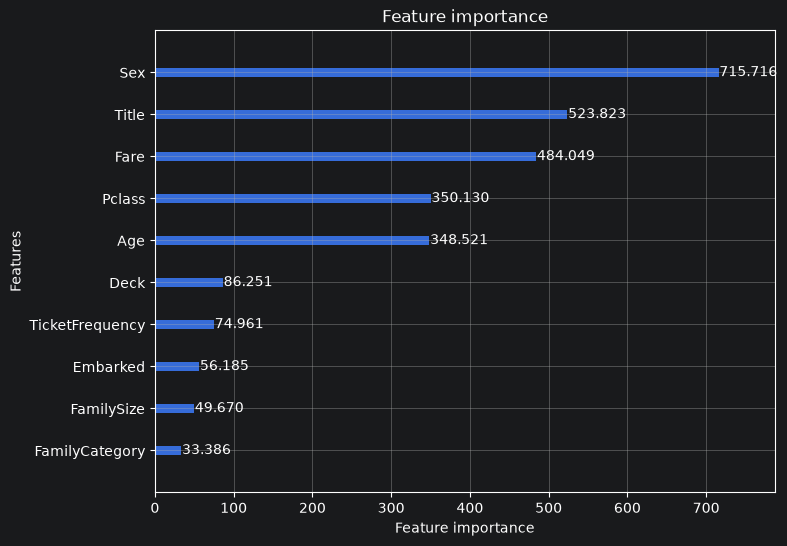

In [26]:
lgb.plot_importance(best_model_lgbm, importance_type='gain', figsize=(8,6))

In [27]:
submission_lgbm = submission(best_model_lgbm, X_tree_test)
submission_lgbm.to_csv("submission_lgbm_4.csv", index=False)